In [117]:
import pandas as pd

In [118]:
dados = pd.read_csv('https://raw.githubusercontent.com/LuizinhoXT/Python/refs/heads/main/machine_learning/nlp_machine_learning/dataset_avaliacoes.csv')

In [119]:
dados.head()

,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo


In [120]:
dados.value_counts('sentimento')

sentimento
positivo    7890
negativo    7611
Name: count, dtype: int64

In [121]:
print('positivo \n\n', dados.avaliacao[0])

positivo 

 Esse smartphone superou minhas expectativas, recomendo


In [122]:
print('negativo \n\n', dados.avaliacao[1])

negativo 

 o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..


In [123]:
from sklearn.feature_extraction.text import CountVectorizer

In [124]:
# teste de vetorização para entender o funcionamento do algoritimo

texto = ['Esse smartphone superou minhas expectativas, recomendo', 'o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..']

vetorizar = CountVectorizer()
bag_of_words = vetorizar.fit_transform(texto)

In [125]:
# Matrix esparsa é o retorno de bag_of_words que acontece quando temos vários 0's dentro de uma matriz
bag_of_words

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 15 stored elements and shape (2, 15)>

In [126]:
# Através da vetorização, criamos uma tabela em que os elementos escalam de maneira horizontal, gerando assim uma classificação binária que avalia se determinada palavra existe ou não exister em determinado registro de dados.

matriz_esparsa = pd.DataFrame.sparse.from_spmatrix(bag_of_words,columns=vetorizar.get_feature_names_out())

matriz_esparsa

,cheiro,desagradavel,esse,expectativas,incomoda,minhas,muito,nao,pra,quem,recomendo,recomendoo,se,smartphone,superou
0,0,0,1,1,0,1,0,0,0,0,1,0,0,1,1
1,1,1,0,0,1,0,1,1,1,1,0,1,1,0,0


In [127]:
# A dimensão na pós vetorização aumenta horizontalmente e isso se mostra no Output dessa célula com +23k de colunas.
# Isso é um problema pois é computacionalmente caro

vetorizar = CountVectorizer(lowercase=False)

bag_of_words = vetorizar.fit_transform(dados.avaliacao)
print(bag_of_words.shape)

(15501, 23352)


In [128]:
# Otimizando o código para limitar a quantidade de features geradas pela vetorização


vetorizar = CountVectorizer(lowercase=False, max_features=50)

bag_of_words = vetorizar.fit_transform(dados.avaliacao)
print(bag_of_words.shape)

# A limitação de features considera as palavras que tem maior ocorrencia dentro da dos dados


(15501, 50)


In [129]:
matriz_esparsa_avaliacoes = pd.DataFrame.sparse.from_spmatrix(bag_of_words, columns= vetorizar.get_feature_names_out())
matriz_esparsa_avaliacoes

,Não,Produto,ainda,antes,as,até,bem,bom,chegou,com,...,qualidade,que,recebi,recomendo,se,sem,tem,um,uma,veio
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,...,1,2,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
15497,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
15498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
15499,0,1,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [130]:
# Separação em treino teste split
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(bag_of_words, dados.sentimento, random_state=4978)

In [131]:
# Aplicando algorítmo de Regressão Logística 
from sklearn.linear_model import LogisticRegression

regresssao_logistica = LogisticRegression()
regresssao_logistica.fit(x_treino, y_treino)
acuracia = regresssao_logistica.score(x_teste, y_teste)
acuracia

0.7982456140350878

- Crie uma função chamada classificar_texto, que aceite três parâmetros: o nome do DataFrame, o nome da coluna contendo as avaliações de texto e o nome da coluna correspondente aos sentimentos;
- Utilize a classe CountVectorizer para transformar o texto em um vetor bag of words, com um número máximo de 50 features;
- Separe os dados em conjuntos de treino e teste utilizando train_test_split;
- Crie um modelo de regressão logística e ajuste-o aos dados de treino;
- Calcule e retorne a acurácia do modelo para os dados de teste;
- Retorne o valor da acurácia.

In [132]:
def classificar_texto(df,col_ava_texto, sentimento):
    
    from sklearn.feature_extraction.text import CountVectorizer
    
    vetorizar = CountVectorizer(lowercase=False, max_features=50)

    bag_of_words = vetorizar.fit_transform(df[col_ava_texto])
    print(bag_of_words.shape)

    from sklearn.model_selection import train_test_split

    x_treino, x_teste, y_treino, y_teste = train_test_split(bag_of_words, dados[sentimento], random_state=4978)
    
    from sklearn.linear_model import LogisticRegression

    regresssao_logistica = LogisticRegression()
    regresssao_logistica.fit(x_treino, y_treino)
    acuracia = regresssao_logistica.score(x_teste, y_teste)
   
    return print(f"\nAcurácia do modelo com a coluna '{col_ava_texto}': {acuracia * 100:.2f}%")

# Essa fuinção facilita o processo de classificação do texto, prevendo futuras avaliações


In [133]:
classificar_texto(dados,'avaliacao','sentimento')


(15501, 50)

Acurácia do modelo com a coluna 'avaliacao': 79.82%


#### Resumo até aqui

- Explorar dados textuais;
- Utilizar a técnica de Bag of words para converter textos em vetores numéricos;
- Separar os dados em treino e teste;
- Treinar o modelo de regressão logística;
- Obter a acurácia do modelo nos dados de teste.

In [134]:
todas_palavras = [texto for texto in dados.avaliacao]
todas_palavras

['Esse smartphone superou minhas expectativas, recomendo',
 'o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..',
 'Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.',
 'Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento.',
 'Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor .',
 'Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!!',
 'o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado',
 'já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen',
 'nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA 

In [135]:
todas_palavras = ' '.join([texto for texto in dados.avaliacao])
todas_palavras

'Esse smartphone superou minhas expectativas, recomendo o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo.. Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra. Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento. Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor . Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!! o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA LOGISTICA. Ja solicitei o cancela

In [136]:
from wordcloud import WordCloud

In [137]:
nuvem_palavras = WordCloud().generate(todas_palavras)

<function matplotlib.pyplot.show(close=None, block=None)>

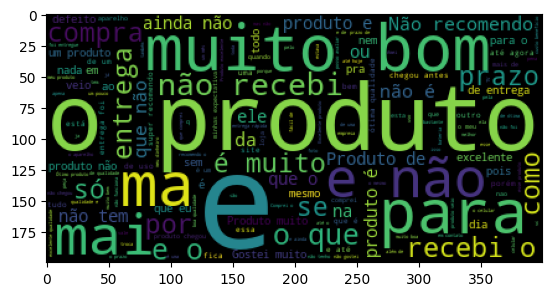

In [138]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(nuvem_palavras)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

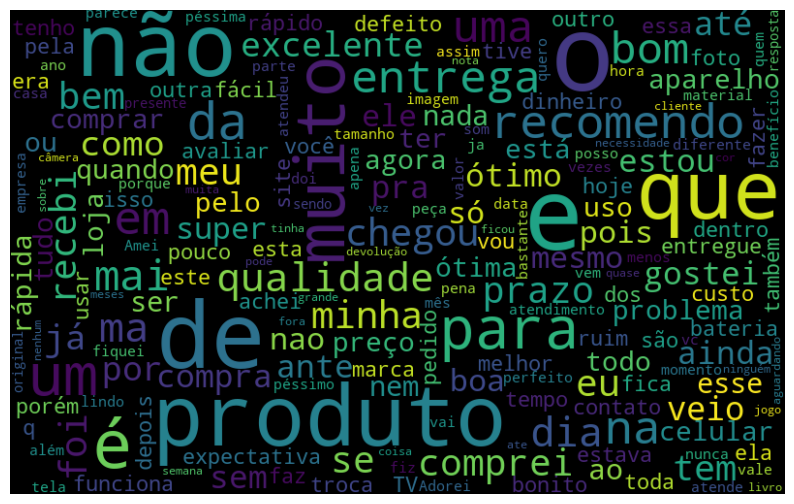

In [139]:
import matplotlib.pyplot as plt

novo_nuvem_palavras = WordCloud(width=800, height=500,max_font_size=110, collocations=False).generate(todas_palavras)

plt.figure(figsize=(10,7))
plt.imshow(novo_nuvem_palavras, interpolation='bilinear')
plt.axis('off')
plt.show

In [140]:
def nuvem_palavras(dados,col_texto,sentimento):
    texto_sentimento = dados.query(f"sentimento == '{sentimento}'")[col_texto]

    texto_unido = ''.join(texto_sentimento)

    nuvem_palavras = WordCloud(width=800, height=500,max_font_size=110, collocations=False).generate(texto_unido)
    plt.figure(figsize=(10,7))
    plt.imshow(nuvem_palavras, interpolation='bilinear')
    plt.axis('off')
    plt.show

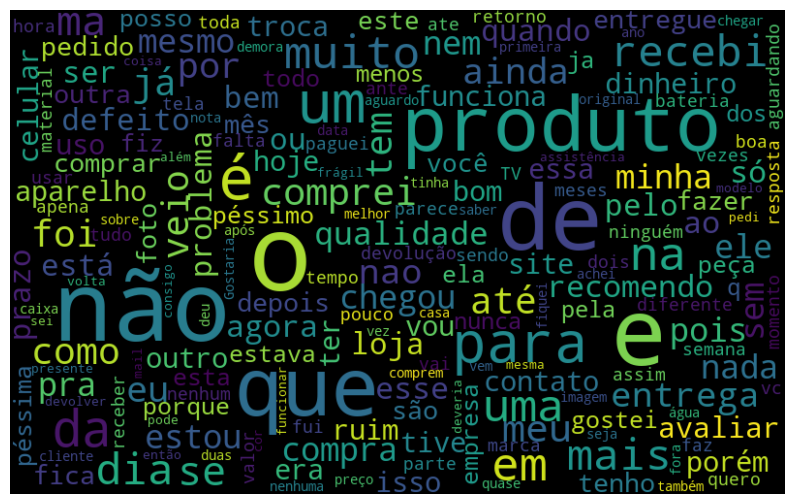

In [141]:
nuvem_palavras(dados,'avaliacao','negativo')

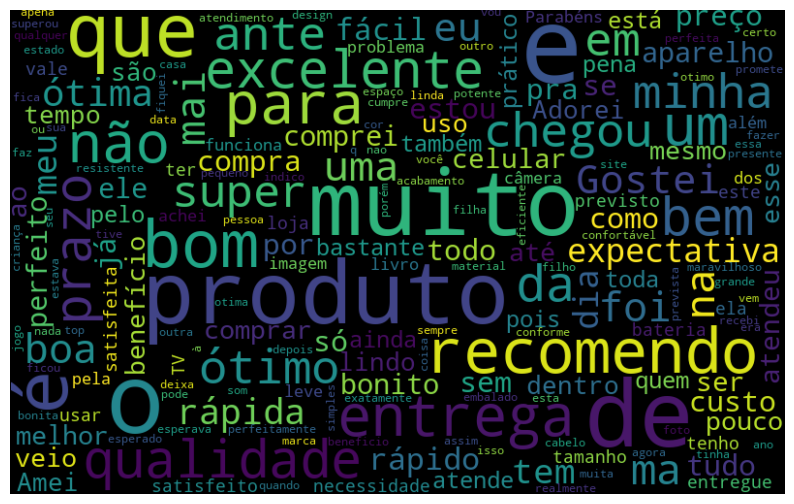

In [142]:
nuvem_palavras(dados,'avaliacao','positivo')

In [143]:
todas_palavras

'Esse smartphone superou minhas expectativas, recomendo o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo.. Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra. Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento. Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor . Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!! o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA LOGISTICA. Ja solicitei o cancela

In [144]:
import nltk

In [145]:
frases = ['um produto bom', 'um produto ruim']

In [146]:
frequencia = nltk.FreqDist(frases)
frequencia

FreqDist({'um produto bom': 1, 'um produto ruim': 1})

In [147]:
# Aplicando o processo de tokenização que irá separar o texto em palavras menores

from nltk import tokenize

frase = 'o produto é excelente e a entrega foi muita rápida!'
token_espaco = tokenize.WhitespaceTokenizer()
token_frase = token_espaco.tokenize(frase)
print(token_frase)

['o', 'produto', 'é', 'excelente', 'e', 'a', 'entrega', 'foi', 'muita', 'rápida!']


In [148]:
token_frase = token_espaco.tokenize(todas_palavras)
frequencia = nltk.FreqDist(token_frase)
frequencia

FreqDist({'e': 11813, 'o': 10865, 'de': 10280, 'a': 8873, 'que': 7657, 'não': 7286, 'é': 4786, 'produto': 4765, 'com': 4641, 'do': 4583, ...})

In [149]:
df_frequencia = pd.DataFrame({'palavra':list(frequencia.keys()),
                              'frequencia':list(frequencia.values())})

In [150]:
df_frequencia.head()

,palavra,frequencia
0,Esse,101
1,smartphone,33
2,superou,90
3,minhas,533
4,"expectativas,",79


In [151]:
df_frequencia.nlargest(columns='frequencia',n=10)


,palavra,frequencia
8,e,11813
6,o,10865
29,de,10280
19,a,8873
46,que,7657
22,não,7286
163,é,4786
63,produto,4765
177,com,4641
130,do,4583


[Text(0, 0.5, 'Contagem')]

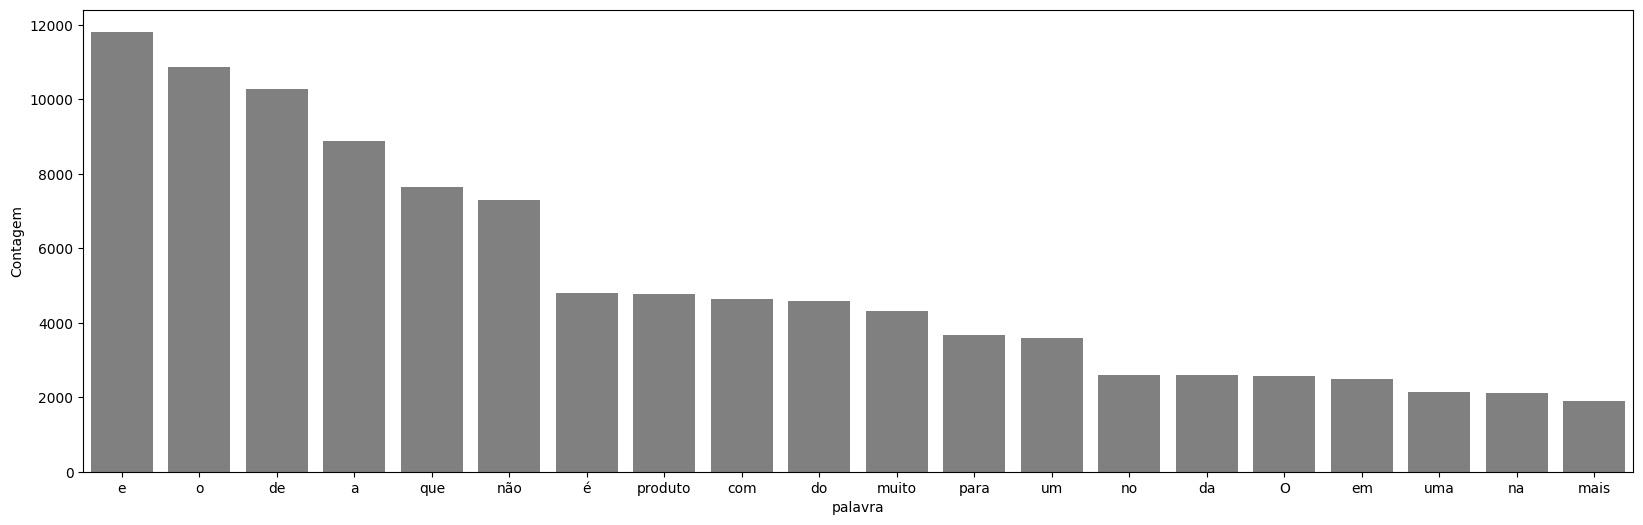

In [152]:
import seaborn as sns

plt.figure(figsize=(20,6))
ax = sns.barplot(df_frequencia.nlargest(columns='frequencia',n=20), x='palavra', y='frequencia',color='grey')
ax.set(ylabel='Contagem')

- Receba três parâmetros: o nome do DataFrame contendo a coluna com o texto, o nome da coluna de texto e a quantidade de palavras mais frequentes a serem exibidas;
- Concatene todas as palavras presentes em uma determinada coluna de um DataFrame;
- Calcule a frequência de cada palavra usando a biblioteca NLTK;
- Converta os resultados em um DataFrame contendo duas colunas: "Palavra" e "Frequência";
- Selecione as palavras mais frequentes, de acordo com a quantidade especificada pelo usuário;
- Plote um gráfico de barras exibindo a frequência dessas palavras utilizando a biblioteca seaborn.

In [153]:
def grafico_frequencia(df,nm_col_ava,qty):

    todas_palavras = ' '.join([texto for texto in df[nm_col_ava]])
    token_frase = token_espaco.tokenize(todas_palavras)
    frequencia = nltk.FreqDist(token_frase)

    df_frequencia = pd.DataFrame({'palavra':list(frequencia.keys()),
                              'frequencia':list(frequencia.values())})
    
    plt.figure(figsize=(20,6))
    ax = sns.barplot(df_frequencia.nlargest(columns='frequencia',n=qty), x='palavra', y='frequencia',color='grey')
    ax.set(ylabel='Contagem')


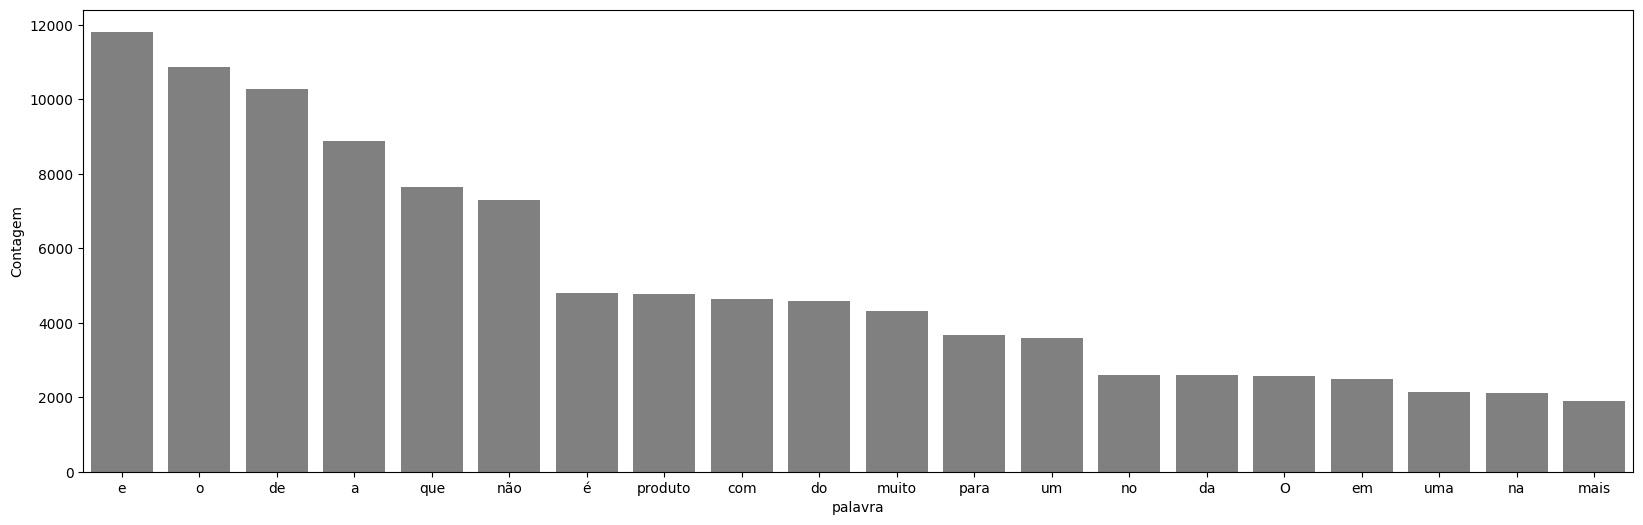

In [154]:
grafico_frequencia(dados,'avaliacao',20)

- Utilizar a biblioteca wordcloud para criar nuvens de palavras;
- Criar uma função para filtrar os sentimentos;
- Aplicar a tokenização com a biblioteca NLTK;
- Calcular a frequência das palavras com a biblioteca NLTK;
- Criar um gráfico com as palavras mais frequentes.

In [155]:
# A biblioteca Nlkt ajuda a criar uma lista de palavras de baixo valor semântico, que depois será utilizada para filtrar os dados do data frame

import nltk

nltk.download("all")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\luizf\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\luizf\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\luizf\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\luizf\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\luizf\AppData\Roaming\nltk_data...
[

True

In [156]:
# Já possui um módulo que mapeia as palavras mais comuns da lingua portuguesa. A bibliotera também possue outras idiomas padrão.
palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese')

In [157]:
# Algoritmo de filtragem de stopwords

def filtro_stopword(df,nm_col_texto):
    palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese') # Definição das palavras irrelevantes da bilbioteca nlkt
    palavras_processadas = [] # Lista vazia para armazenar o processamento da função
    token_espaco = tokenize.WhitespaceTokenizer() # instancia do tokenizaddor

    for avaliacao in df[nm_col_texto]:
        token_palavras = token_espaco.tokenize(avaliacao) # Aplicação do tokem com base no espaço
        nova_frase = [palavra for palavra in token_palavras if palavra not in palavras_irrelevantes] # sub-laço for filtrando as palavras que não devem estar no final
        palavras_processadas.append(' '.join(nova_frase)) # Append das palavras processadas
    
    return palavras_processadas # Retorno dos daod processados

In [158]:
dados['tratamento_1'] = filtro_stopword(dados,'avaliacao')

In [159]:
dados.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou expectativas, recomendo"
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,cheiro desagradavel!! pra incomoda nao recomen...
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz compra loja entregou produto, compra fe..."
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu expectativas, achei luz ruim, nada dif..."
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, achei ficou desejar qualidade fo..."


In [160]:
dados["avaliacao"][0]

'Esse smartphone superou minhas expectativas, recomendo'

In [161]:
dados['tratamento_1'][1]

'cheiro desagradavel!! pra incomoda nao recomendoo..'

In [162]:
dados['avaliacao'][2]


'Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.'

In [163]:
dados['tratamento_1'][2]


'Eu fiz compra loja entregou produto, compra feita cartão credito ate momento loja nao devolveu valor compra.'

In [164]:
classificar_texto(dados,'tratamento_1','sentimento')

(15501, 50)

Acurácia do modelo com a coluna 'tratamento_1': 81.09%


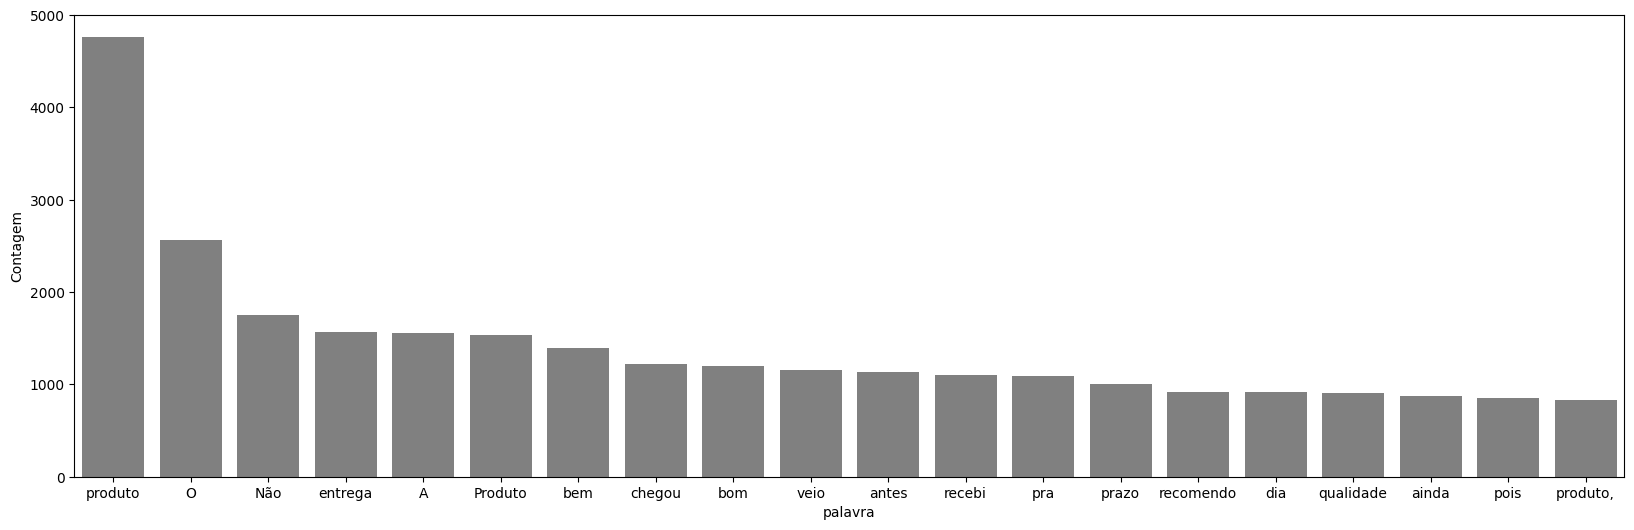

In [165]:
grafico_frequencia(dados,'tratamento_1',20)

In [166]:
frase = 'Esse smartphone superou minhas expectativas, recomendo!'

In [167]:

token_pontuacao = tokenize.WordPunctTokenizer()
token_frase = token_pontuacao.tokenize(frase)
token_frase

['Esse',
 'smartphone',
 'superou',
 'minhas',
 'expectativas',
 ',',
 'recomendo',
 '!']

In [168]:
# Algoritmo de filtragem de stopwords

def filtro_alfanumerico_stopword(df,nm_col_texto):
    palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese') # Definição das palavras irrelevantes da bilbioteca nlkt
    palavras_processadas = [] # Lista vazia para armazenar o processamento da função
    token_pontuacao = tokenize.WordPunctTokenizer() # instancia do tokenizador que também separa em tokensm tudo que é alfánumérico incluíndo potuações

    for avaliacao in df[nm_col_texto]:
        token_palavras = token_pontuacao.tokenize(avaliacao) # Aplicação do tokem com base no espaço
        nova_frase = [palavra for palavra in token_palavras if palavra.isalpha() and palavra not in palavras_irrelevantes] # sub-laço for filtrando as palavras que não devem estar processamento final e eliminando os caracteres alfanuméricos
        palavras_processadas.append(' '.join(nova_frase)) # Append das palavras processadas
    
    return palavras_processadas # Retorno dos daod processados

In [169]:
dados['tratamento_2'] = filtro_alfanumerico_stopword(dados,'tratamento_1')

In [170]:
dados['tratamento_2'][10]

'Melhor esperado cor maravilhosa Recomendo Deixa ambiente moderno'

In [171]:
dados['tratamento_1'][10]

'Melhor esperado, cor maravilhosa! Recomendo. Deixa ambiente moderno'

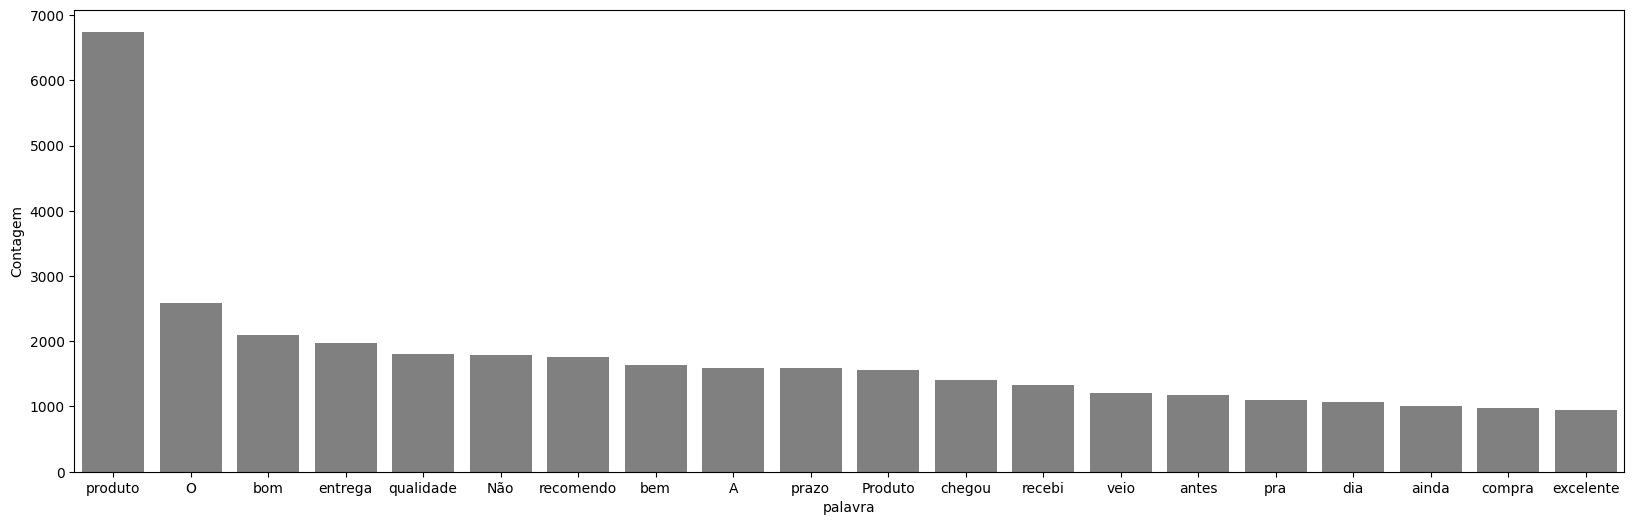

In [172]:
grafico_frequencia(dados,'tratamento_2',20)

In [173]:
import unidecode

In [174]:
sem_acento = [unidecode.unidecode(texto) for texto in dados['tratamento_2']]

In [175]:
stopwords_sem_acento = [unidecode.unidecode(texto) for texto in palavras_irrelevantes]

In [176]:
# Algoritmo de filtragem de stopwords

def filtro_stopword_alfanumerico_sem_acento(df,nm_col_texto):
    
    sem_acento = [unidecode.unidecode(texto.lower()) for texto in df[nm_col_texto]] # Aplicando a uniformuzação do texto e removendo a acentuação da coluna antes da tokenização
    df[nm_col_texto] = sem_acento # Atruibuição da coluna sem acentuação
    palavras_irrelevantes =  nltk.corpus.stopwords.words('portuguese') # Definição das palavras irrelevantes da bilbioteca nlkt
    palavras_irrelevantes_sem_acento = [unidecode.unidecode(texto) for texto in palavras_irrelevantes] # Retirando a acentuacao das palavras irrelevantes
    palavras_processadas = [] # Lista vazia para armazenar o processamento da função
    token_pontuacao = tokenize.WordPunctTokenizer() # instancia do tokenizador que também separa em tokensm tudo que é alfánumérico incluíndo potuações

    for avaliacao in df[nm_col_texto]:
        token_palavras = token_pontuacao.tokenize(avaliacao) # Aplicação do tokem com base no espaço
        nova_frase = [palavra for palavra in token_palavras if palavra.isalpha() and palavra not in palavras_irrelevantes_sem_acento] # sub-laço for filtrando as palavras que não devem estar processamento final e eliminando os caracteres alfanuméricos
        palavras_processadas.append(' '.join(nova_frase)) # Append das palavras processadas
    
    return palavras_processadas # Retorno dos dados processados

In [177]:
dados['tratamento_3'] = filtro_stopword_alfanumerico_sem_acento(dados,'avaliacao')

In [178]:
dados['tratamento_4'] = filtro_stopword_alfanumerico_sem_acento(dados,'avaliacao')

In [179]:
dados['tratamento_2'][70]

'Melhor compra fiz últimos tempos Produto barato útil Produto robusto leve O teclado proporciona digitação confortável mouse preciso O teclado mouse usam apenas receptor economizando número portas USB computador Me livrei incomodo fios espaço trabalho ficou limpo harmonioso Ademais tudo parece bastante durável safisfeito Recomendo todos'

In [180]:
dados['tratamento_3'][70]

'melhor compra fiz ultimos tempos produto barato util produto robusto leve teclado proporciona digitacao confortavel mouse preciso teclado mouse usam apenas receptor economizando numero portas usb computador livrei incomodo fios espaco trabalho ficou limpo harmonioso ademais tudo parece bastante duravel safisfeito recomendo todos'

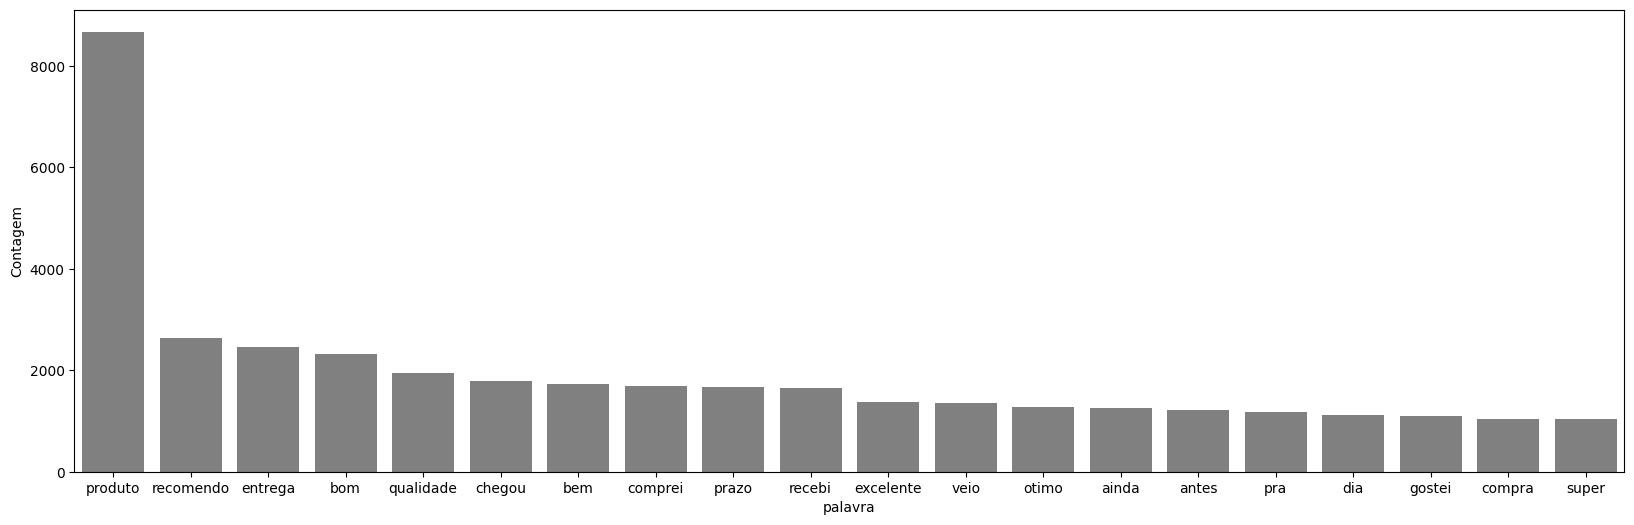

In [181]:
grafico_frequencia(dados, 'tratamento_3', 20)

In [182]:
dados['tratamento_3'][3]

'atendeu expectativas achei luz ruim nada dificulte funcionamento'

In [183]:
dados['tratamento_4'][3]

'atendeu expectativas achei luz ruim nada dificulte funcionamento'

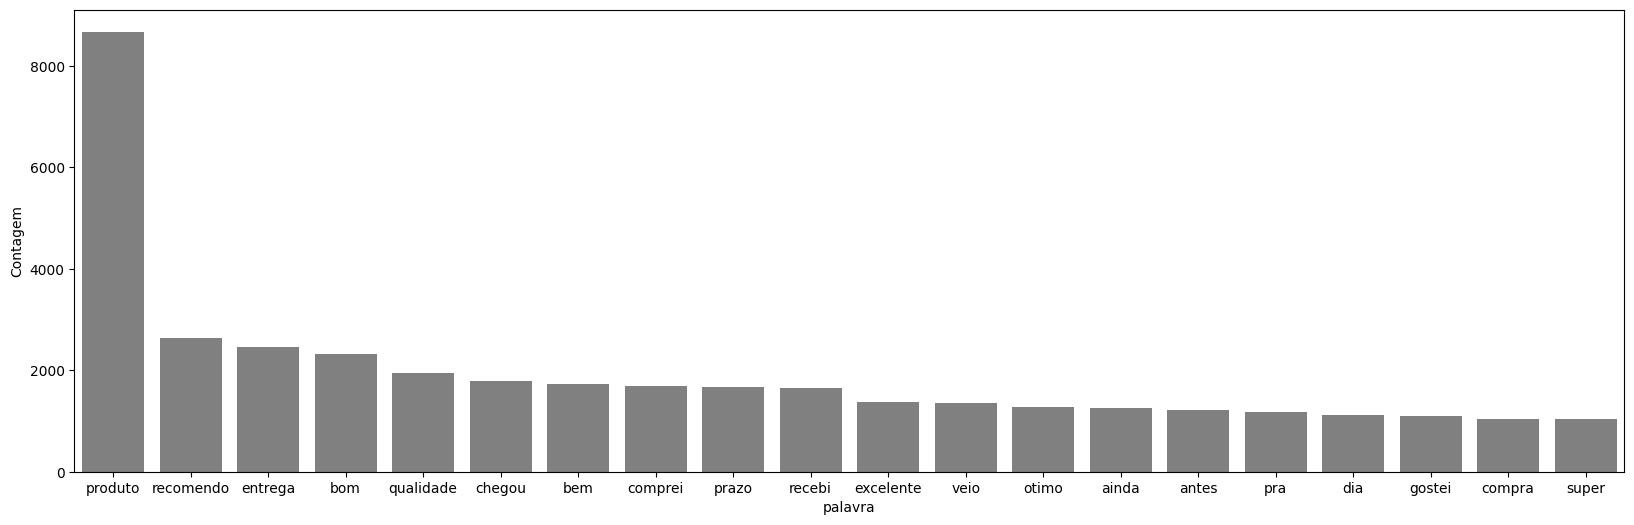

In [184]:
grafico_frequencia(dados, 'tratamento_4', 20)

In [185]:
classificar_texto(dados,'tratamento_1', 'sentimento')

(15501, 50)

Acurácia do modelo com a coluna 'tratamento_1': 81.09%


In [186]:
classificar_texto(dados,'tratamento_4', 'sentimento')

(15501, 50)

Acurácia do modelo com a coluna 'tratamento_4': 83.75%


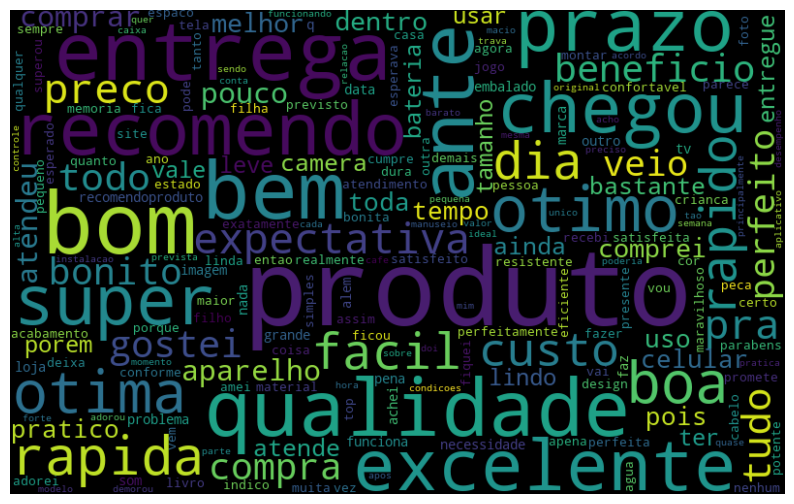

In [187]:
nuvem_palavras(dados,'tratamento_4','positivo')

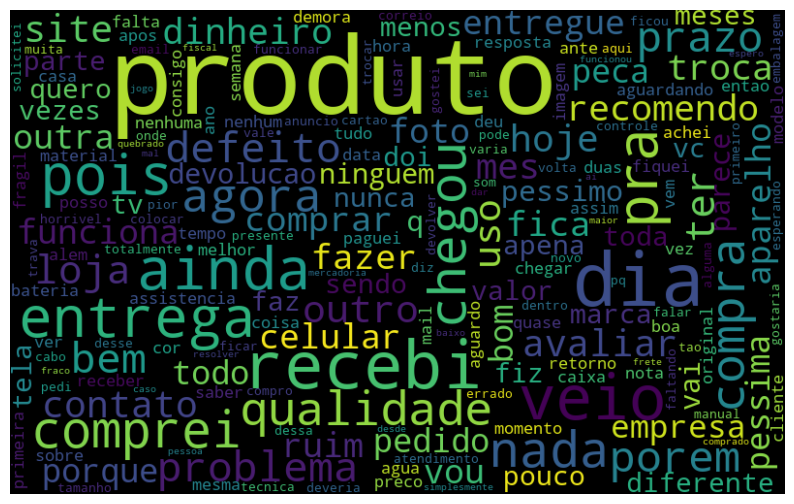

In [188]:
nuvem_palavras(dados,'tratamento_4','negativo')

- Importar uma lista de stopwords com a biblioteca NLTK;
- Realizar a tokenização por pontuação;
- Realizar o tratamento para remover a pontuação de um texto;
- Remover acentos com a biblioteca unidecode;
- Transformar todos os caracteres em minúsculo.

In [189]:
# simplificando palavras com baase em seu radical

stemmer = nltk.RSLPStemmer()

stemmer.stem('Gostando')

'gost'

In [190]:
# Algoritmo de filtragem de stopwords

def filtro_stopword_alfanumerico_sem_acento_stemmer(df,nm_col_texto):
    stemmer = nltk.RSLPStemmer() # instancia do stemmer
    sem_acento = [unidecode.unidecode(texto.lower()) for texto in df[nm_col_texto]] # Aplicando a uniformuzação do texto e removendo a acentuação da coluna antes da tokenização
    df[nm_col_texto] = sem_acento # Atruibuição da coluna sem acentuação
    palavras_irrelevantes =  nltk.corpus.stopwords.words('portuguese') # Definição das palavras irrelevantes da bilbioteca nlkt
    palavras_irrelevantes_sem_acento = [unidecode.unidecode(texto) for texto in palavras_irrelevantes] # Retirando a acentuacao das palavras irrelevantes
    palavras_processadas = [] # Lista vazia para armazenar o processamento da função
    token_pontuacao = tokenize.WordPunctTokenizer() # instancia do tokenizador que também separa em tokensm tudo que é alfánumérico incluíndo potuações

    for avaliacao in df[nm_col_texto]:
        token_palavras = token_pontuacao.tokenize(avaliacao) # Aplicação do tokem com base no espaço
        nova_frase = [stemmer.stem(palavra) for palavra in token_palavras if palavra.isalpha() and palavra not in palavras_irrelevantes_sem_acento] # sub-laço for filtrando as palavras que não devem estar processamento final e eliminando os caracteres alfanuméricos + redução pelo radical
        palavras_processadas.append(' '.join(nova_frase)) # Append das palavras processadas
    
    return palavras_processadas # Retorno dos dados processados

In [191]:
dados['tratamento_5'] = filtro_stopword_alfanumerico_sem_acento_stemmer(dados, 'avaliacao')

In [192]:
dados['tratamento_4'][3]

'atendeu expectativas achei luz ruim nada dificulte funcionamento'

In [193]:
dados['tratamento_5'][3]


'atend expect ach luz ruim nad dificult funcion'

In [194]:
classificar_texto(dados,'tratamento_5', 'sentimento')

(15501, 50)

Acurácia do modelo com a coluna 'tratamento_5': 85.11%


In [195]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [196]:
frase = ['Comprei um ótimo produto', 'Comprei um produto péssimo']

tfidf = TfidfVectorizer(lowercase=False, max_features=50)
matriz = tfidf.fit_transform(frase)
pd.DataFrame(matriz.todense(), 
             columns=tfidf.get_feature_names_out())

,Comprei,produto,péssimo,um,ótimo
0,0.448321,0.448321,0.000000,0.448321,0.630099
1,0.448321,0.448321,0.630099,0.448321,0.000000


In [197]:
tfidf_bruto = tfidf.fit_transform(dados['avaliacao'])
x_treinoo, x_testee, y_treinoo, y_testee = train_test_split(tfidf_bruto, dados['sentimento'], random_state=4978) 

regresssao_logistica.fit(x_treinoo, y_treinoo)
acuracia_tfidf_bruto = regresssao_logistica.score(x_testee, y_testee)
print(f'acuracia do modelo: {acuracia_tfidf_bruto * 100:.2f}%')

acuracia do modelo: 85.24%


In [198]:

tfidf = TfidfVectorizer(lowercase=False, max_features=50)
tfidf_trratados = tfidf.fit_transform(dados['tratamento_5'])
x_treinoo, x_testee, y_treinoo, y_testee = train_test_split(tfidf_trratados, dados['sentimento'], random_state=4978) 

regresssao_logistica.fit(x_treinoo, y_treinoo)
acuracia_tfidf_tratado = regresssao_logistica.score(x_testee, y_testee)
print(f'acuracia do modelo: {acuracia_tfidf_tratado * 100:.2f}%')

acuracia do modelo: 85.14%


In [199]:
def classificar_texto_tfidf(df,col_ava_texto, sentimento):
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    
    tfidf = TfidfVectorizer(lowercase=False, max_features=50)

    vetorizar = tfidf.fit_transform(df[col_ava_texto])
    

    from sklearn.model_selection import train_test_split

    x_treino, x_teste, y_treino, y_teste = train_test_split(vetorizar, dados[sentimento], random_state=4978)
    
    from sklearn.linear_model import LogisticRegression

    regresssao_logistica = LogisticRegression()
    regresssao_logistica.fit(x_treino, y_treino)
    acuracia = regresssao_logistica.score(x_teste, y_teste)
   
    return print(f"\nAcurácia do modelo com a coluna '{col_ava_texto}': {acuracia * 100:.2f}%")

# Essa fuinção facilita o processo de classificação do texto, prevendo futuras avaliações


In [200]:
classificar_texto_tfidf(dados, 'tratamento_5', 'sentimento')


Acurácia do modelo com a coluna 'tratamento_5': 85.14%


In [201]:
from nltk import ngrams
text = 'Comprei um produto ótimo'
frase_separada  = token_espaco.tokenize(text)
pares = ngrams(frase_separada, 2)
list(pares)

[('Comprei', 'um'), ('um', 'produto'), ('produto', 'ótimo')]

In [202]:
def classificar_texto_tfidf_ngrams(df,feature_x, feature_y, num_features):
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    
    tfidf = TfidfVectorizer(lowercase=False, max_features=num_features,ngram_range=(1,2))

    vetorizar = tfidf.fit_transform(df[feature_x])
    
    from sklearn.model_selection import train_test_split

    x_treino, x_teste, y_treino, y_teste = train_test_split(vetorizar, dados[feature_y], random_state=4978)
    
    from sklearn.linear_model import LogisticRegression

    regresssao_logistica = LogisticRegression()
    regresssao_logistica.fit(x_treino, y_treino)
    acuracia = regresssao_logistica.score(x_teste, y_teste)

    pesos = pd.DataFrame(
        regresssao_logistica.coef_[0].T,
        index= tfidf.get_feature_names_out()
    )
    
    pesos.nlargest(50,0).head
    
    pesos.nsmallest(50,0).head

    return pesos, print(f"Dimensão vetor tfifd '{vetorizar.shape}'\n\nAcurácia do modelo com a coluna '{feature_x}' e '{num_features}' features: {acuracia * 100:.2f}%")

# Essa fuinção facilita o processo de classificação do texto, prevendo futuras avaliações


In [203]:
from sklearn.feature_extraction.text import TfidfVectorizer
    
tfidf = TfidfVectorizer(lowercase=False, max_features=1000,ngram_range=(1,2))

vetorizar = tfidf.fit_transform(dados['tratamento_5'])
    
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(vetorizar, dados['sentimento'], random_state=4978)
    
from sklearn.linear_model import LogisticRegression

regresssao_logistica = LogisticRegression()
regresssao_logistica.fit(x_treino, y_treino)
acuracia = regresssao_logistica.score(x_teste, y_teste)

pesos = pd.DataFrame(
    regresssao_logistica.coef_[0].T,
    index= tfidf.get_feature_names_out()
)
    
pesos.nlargest(50,0).head
    
pesos.nsmallest(50,0).head

print(f"Dimensão vetor tfifd '{vetorizar.shape}'\n\nAcurácia do modelo com a coluna 'tratamento_5' e '1000' features: {acuracia * 100:.2f}%")

Dimensão vetor tfifd '(15501, 1000)'

Acurácia do modelo com a coluna 'tratamento_5' e '1000' features: 91.82%


In [204]:
classificar_texto_tfidf_ngrams(dados,'tratamento_5', 'sentimento', 50)

Dimensão vetor tfifd '(15501, 50)'

Acurácia do modelo com a coluna 'tratamento_5' e '50' features: 85.22%


(                     0
 ach          -0.286051
 agor         -0.658566
 aind         -1.034472
 ant           2.178939
 ant praz      2.187972
 aparelh      -0.165367
 atend         1.928214
 bem           1.368903
 boa           1.739629
 bom           3.683908
 celul        -0.432159
 cheg         -0.754508
 compr        -0.834494
 dia          -1.132708
 entreg       -0.209186
 esper        -0.078104
 excel         6.313294
 facil         1.759070
 faz          -0.703606
 fic          -1.293188
 gost          1.877074
 loj          -0.763269
 melhor        0.967983
 nad          -1.827607
 otim          5.909038
 outr         -0.881186
 ped          -1.857524
 perfeit       4.230671
 pess         -4.946750
 pod           0.035812
 poi          -1.380389
 por          -1.444421
 pra           0.520228
 praz          1.591472
 problem      -0.768788
 produt       -0.747572
 qual          0.264101
 rap           3.202844
 receb        -2.861255
 receb produt -2.074958
 recom         1

In [205]:
classificar_texto_tfidf_ngrams(dados,'tratamento_5', 'sentimento', 100)

Dimensão vetor tfifd '(15501, 100)'

Acurácia do modelo com a coluna 'tratamento_5' e '100' features: 88.18%


(               0
 acab   -0.286373
 ach    -0.343872
 ador    4.887738
 agor   -0.269820
 aguard -2.131632
 ...          ...
 val     0.342595
 vei    -2.321465
 vend   -1.153271
 vez    -0.778499
 vou    -0.916649
 
 [100 rows x 1 columns],
 None)

In [206]:
pesos, msg = classificar_texto_tfidf_ngrams(dados,'tratamento_5', 'sentimento', 1000)



Dimensão vetor tfifd '(15501, 1000)'

Acurácia do modelo com a coluna 'tratamento_5' e '1000' features: 91.82%


In [207]:
pesos.nlargest(50,0)

,0
otim,7.780210
excel,7.434005
bom,6.010135
perfeit,5.089660
ador,5.051001
satisfeit,4.839361
rap,4.121781
lind,3.783865
ame,3.523977
maravilh,3.487160


In [208]:
pesos.nsmallest(50,0)


,0
pess,-4.640200
ruim,-4.062400
receb,-4.060175
frac,-3.715877
horri,-3.380245
fragil,-3.036899
defeit,-3.035303
devolv,-2.937863
decepcion,-2.892754
dinh,-2.701879


In [238]:
import joblib

joblib.dump(tfidf, 'tfidf_vectorizer.plk')
joblib.dump(regresssao_logistica, 'modelo_regresssao_logistica.plk')


['modelo_regresssao_logistica.plk']

In [235]:
tfidf = joblib.load('tfidf_vectorizer.plk')
regresssao_logisticaa = joblib.load('modelo_regresssao_logistica.plk')


### Função de processamento de texto final 

In [ ]:
# Algoritmo de filtragem de stopwords

def filtro_stopword_alfanumerico_sem_acento_stemmer(df,nm_col_texto):
    stemmer = nltk.RSLPStemmer() # instancia do stemmer
    sem_acento = [unidecode.unidecode(texto.lower()) for texto in df[nm_col_texto]] # Aplicando a uniformuzação do texto e removendo a acentuação da coluna antes da tokenização
    df[nm_col_texto] = sem_acento # Atruibuição da coluna sem acentuação
    palavras_irrelevantes =  nltk.corpus.stopwords.words('portuguese') # Definição das palavras irrelevantes da bilbioteca nlkt
    palavras_irrelevantes_sem_acento = [unidecode.unidecode(texto) for texto in palavras_irrelevantes] # Retirando a acentuacao das palavras irrelevantes
    palavras_processadas = [] # Lista vazia para armazenar o processamento da função
    token_pontuacao = tokenize.WordPunctTokenizer() # instancia do tokenizador que também separa em tokensm tudo que é alfánumérico incluíndo potuações

    for avaliacao in df[nm_col_texto]:
        token_palavras = token_pontuacao.tokenize(avaliacao) # Aplicação do tokem com base no espaço
        nova_frase = [stemmer.stem(palavra) for palavra in token_palavras if palavra.isalpha() and palavra not in palavras_irrelevantes_sem_acento] # sub-laço for filtrando as palavras que não devem estar processamento final e eliminando os caracteres alfanuméricos + redução pelo radical
        palavras_processadas.append(' '.join(nova_frase)) # Append das palavras processadas
    
    return palavras_processadas # Retorno dos dados processados

In [ ]:
dados['Tratamento_final'] = filtro_stopword_alfanumerico_sem_acento_stemmer(dados,'avaliacao')

In [219]:
dados.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1,tratamento_2,tratamento_3,tratamento_4,tratamento_5,Tratamento_final
0,81841,"esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou expectativas, recomendo",Esse smartphone superou expectativas recomendo,smartphone superou expectativas recomendo,smartphone superou expectativas recomendo,smartphon super expect recom,smartphon super expect recom
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,cheiro desagradavel!! pra incomoda nao recomen...,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda recomendoo,cheiro desagradavel pra incomoda recomendoo,cheir desagrada pra incomod recomendo,cheir desagrada pra incomod recomendo
2,91332,"eu fiz a compra a loja nao entregou o produto,...",1,negativo,"Eu fiz compra loja entregou produto, compra fe...",Eu fiz compra loja entregou produto compra fei...,fiz compra loja entregou produto compra feita ...,fiz compra loja entregou produto compra feita ...,fiz compr loj entreg produt compr feit carta c...,fiz compr loj entreg produt compr feit carta c...
3,110045,"atendeu minhas expectativas, so achei a luz ru...",4,positivo,"Atendeu expectativas, achei luz ruim, nada dif...",Atendeu expectativas achei luz ruim nada dific...,atendeu expectativas achei luz ruim nada dific...,atendeu expectativas achei luz ruim nada dific...,atend expect ach luz ruim nad dificult funcion,atend expect ach luz ruim nad dificult funcion
4,36929,"gostei muito, so achei que ficou a desejar a q...",5,positivo,"Gostei muito, achei ficou desejar qualidade fo...",Gostei achei ficou desejar qualidade fotos Ach...,gostei achei ficou desejar qualidade fotos ach...,gostei achei ficou desejar qualidade fotos ach...,gost ach fic desej qual fot ach bem melhor,gost ach fic desej qual fot ach bem melhor


### Funçao de Treinamento final

In [224]:
def classificar_texto_tfidf_ngrams_md(modelo_treinado,df,feature_x, feature_y, num_features):
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    
    tfidf = TfidfVectorizer(lowercase=False, max_features=num_features,ngram_range=(1,2))

    vetorizar = tfidf.fit_transform(df[feature_x])
    
    from sklearn.model_selection import train_test_split

    x_treino, x_teste, y_treino, y_teste = train_test_split(vetorizar, dados[feature_y], random_state=4978)
    
    from sklearn.linear_model import LogisticRegression

    modelo_treinado.fit(x_treino, y_treino)
    acuracia = modelo_treinado.score(x_teste, y_teste)

    pesos = pd.DataFrame(
        modelo_treinado.coef_[0].T,
        index= tfidf.get_feature_names_out()
    )
    msg = f"Dimensão vetor tfifd '{vetorizar.shape}'\n\nAcurácia do modelo com a coluna '{feature_x}' e '{num_features}' features: {acuracia * 100:.2f}%"
    
    print(msg)
    
    return pesos, msg

# Essa fuinção facilita o processo de classificação do texto, prevendo futuras avaliações


In [225]:
df, msg = classificar_texto_tfidf_ngrams_md(regresssao_logisticaa,dados,'Tratamento_final','sentimento',1000)

Dimensão vetor tfifd '(15501, 1000)'

Acurácia do modelo com a coluna 'Tratamento_final' e '1000' features: 91.82%


In [229]:
novas_avaliacoes = ["Ótimo produto, super recomendo!",
                 "A entrega atrasou muito! Estou decepcionado com a compra",
                 "Muito satisfeito com a compra. Além de ter atendido as expectativas, o preço foi ótimo",
                 "Horrível!!! O produto chegou danificado e agora estou tentando fazer a devolução.",
                 '''Rastreando o pacote, achei que não fosse recebê-lo, pois, na data prevista, estava sendo entregue em outra cidade.
                 Mas, no fim, deu tudo certo e recebi o produto.Produto de ótima qualidade, atendendo bem as minhas necessidades e por
                 um preço super em conta.Recomendo.''']

In [228]:
palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese')
token_pontuacao = tokenize.WordPunctTokenizer()
stemmer = nltk.RSLPStemmer()

def processar_avaliacao(avaliacao):
  # passo 1
  tokens = token_pontuacao.tokenize(avaliacao)

  # passo 2
  frase_processada = [palavra for palavra in tokens if palavra.lower() not in palavras_irrelevantes]

  # passo 3
  frase_processada = [palavra for palavra in frase_processada if palavra.isalpha()]

  # passo 4
  frase_processada = [unidecode.unidecode(palavra) for palavra in frase_processada]

  # passo 5
  frase_processada = [stemmer.stem(palavra) for palavra in frase_processada]

  return ' '.join(frase_processada)

In [230]:
novas_avaliacoes_processadas = [processar_avaliacao(avaliacao) for avaliacao in novas_avaliacoes]

In [232]:
novas_avaliacoes_processadas

['otim produt sup recom',
 'entreg atras decepcion compr',
 'satisfeit compr alem ter atend expect prec otim',
 'horri produt cheg danific agor tent faz devoluca',
 'rastre pacot ach receb lo poi dat prev send entreg outr cidad fim deu tud cert receb produt produt otim qual atend bem necess prec sup cont recom']

In [231]:
novas_avaliacoes_tf_idf = tfidf.transform(novas_avaliacoes_processadas)

In [239]:
tfidf = joblib.load('tfidf_vectorizer.plk')
regresssao_logisticaa = joblib.load('modelo_regresssao_logistica.plk')

In [241]:
novas_avaliacoes_tfidf = tfidf.transform(novas_avaliacoes_processadas)

predicoes = regresssao_logisticaa.predict(novas_avaliacoes_tfidf)

df_previsoes = pd.DataFrame({
    'Avaliação': novas_avaliacoes,
    'Sentimento previsto': predicoes
})

df_previsoes

,Avaliação,Sentimento previsto
0,"Ótimo produto, super recomendo!",positivo
1,A entrega atrasou muito! Estou decepcionado co...,negativo
2,Muito satisfeito com a compra. Além de ter ate...,positivo
3,Horrível!!! O produto chegou danificado e agor...,negativo
4,"Rastreando o pacote, achei que não fosse receb...",positivo


- Salvar o modelo TF-IDF e o modelo de regressão logística treinados;
- Carregar o TF-IDF e o modelo de regressão logística;
- Criar uma função para processar novas avaliações;
- Aplicar o TF-IDF e o modelo de regressão logística aos dados novos;
- Obter um DataFrame com as classificações dos sentimentos.